In [1]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import shutil
import os
import json

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
CONFIG = {
    "drive_train_dir": "/content/drive/MyDrive/Emotions Dataset/train",
    "drive_validation_dir": "/content/drive/MyDrive/Emotions Dataset/test",
    "local_train_dir": "/content/train",
    "local_validation_dir": "/content/validation",
    "image_size": (224, 224),
    "batch_size": 32,
    "num_classes": 3,
    "class_names": ["angry", "happy", "sad"],
    "epochs": 30,
    "learning_rate": 0.001,
    "model_type": "E_combined_lowlight"
}

In [4]:
print("Copying data from Google Drive to local Colab storage")

# Copy data from Drive to local Colab storage for faster access
if not os.path.exists(CONFIG["local_train_dir"]):
    print("Copying training data to local storage")
    shutil.copytree(CONFIG["drive_train_dir"], CONFIG["local_train_dir"])
    print("Training data copied successfully")

if not os.path.exists(CONFIG["local_validation_dir"]):
    print("Copying validation data to local storage")
    shutil.copytree(CONFIG["drive_validation_dir"], CONFIG["local_validation_dir"])
    print("Validation data copied successfully")

Copying data from Google Drive to local Colab storage
Copying training data to local storage
Training data copied successfully
Copying validation data to local storage
Validation data copied successfully


In [5]:
print("Step 1: Loading pre-trained EfficientNetB0")

# Create the model architecture without weights
base_model = EfficientNetB0(weights=None,
                            include_top=False)

# Build the model with the correct shape
batch_input_shape = (None, 256, 256, 3)
base_model.build(batch_input_shape)

# Load the weights
weights_path = tf.keras.utils.get_file(
    'efficientnetb0_notop.h5',
    'https://storage.googleapis.com/keras-applications/efficientnetb0_notop.h5',
    cache_subdir='models'
)
base_model.load_weights(weights_path)

base_model.trainable = False

print(f"Number of layers: {len(base_model.layers)}")

Step 1: Loading pre-trained EfficientNetB0
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Number of layers: 237


In [6]:
print("Step 2: Mild low-light preprocessing for BOTH training and inference")

def mild_lowlight_preprocess(image):
    # Convert to float for transformations
    image = tf.cast(image, tf.float32)

    image = preprocess_input(image)

    # Gentle darkening
    gamma = 1.3
    image = tf.image.adjust_gamma(image, gamma=gamma)

    # Slight brightness reduction
    brightness_delta = 0.1
    image = image * (1.0 - brightness_delta)

    # Minimal noise
    noise_stddev = 0.03
    noise = tf.random.normal(shape=tf.shape(image), mean=0.0, stddev=noise_stddev)
    image = image + noise
    image = tf.clip_by_value(image, -255.0, 255.0)

    return image


Step 2: Mild low-light preprocessing for BOTH training and inference


In [7]:
print("Step 3: Preparing data generators with consistent low-light preprocessing")

# Training data generator with mild low-light preprocessing
train_datagen = ImageDataGenerator(
    preprocessing_function=mild_lowlight_preprocess,
    rotation_range=15,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.7, 1.3],
    zoom_range=0.1,
    shear_range=0.05,
    fill_mode='nearest'
)

# Validation data generator with same mild low-light preprocessing
validation_datagen = ImageDataGenerator(
    preprocessing_function=mild_lowlight_preprocess
)

# Create data generators
train_generator = train_datagen.flow_from_directory(
    CONFIG["local_train_dir"],
    target_size=CONFIG["image_size"],
    batch_size=CONFIG["batch_size"],
    class_mode='categorical',
    color_mode='rgb',
    shuffle=True,
    classes=CONFIG["class_names"]
)

validation_generator = validation_datagen.flow_from_directory(
    CONFIG["local_validation_dir"],
    target_size=CONFIG["image_size"],
    batch_size=CONFIG["batch_size"],
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False,
    classes=CONFIG["class_names"]
)

print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {validation_generator.samples}")
print(f"Class indices: {train_generator.class_indices}")

Step 3: Preparing data generators with consistent low-light preprocessing
Found 6799 images belonging to 3 classes.
Found 2278 images belonging to 3 classes.
Training samples: 6799
Validation samples: 2278
Class indices: {'angry': 0, 'happy': 1, 'sad': 2}


In [8]:
print("Step 4: Building the model architecture")


model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(CONFIG["num_classes"], activation='softmax')
])

model.summary()

Step 4: Building the model architecture


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, None, None,     │     4,049,571 │
│                                 │ 1280)                  │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,378,278 (16.70 MB)

 Trainable params: 328,707 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [9]:
print("Step 5: Compiling the model")

# Callbacks
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    f"model_E_combined_lowlight_best.h5",
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.TopKCategoricalAccuracy(k=2, name='top_2_accuracy')]
)

Step 5: Compiling the model


In [10]:
print("Step 6: Training the model")

# Calculate steps per epoch
steps_per_epoch = train_generator.samples // train_generator.batch_size
validation_steps = validation_generator.samples // validation_generator.batch_size

print(f"Steps per epoch: {steps_per_epoch}")
print(f"Validation steps: {validation_steps}")

# Train the model
history = model.fit(
    train_generator,
    epochs=CONFIG["epochs"],
    validation_data=validation_generator,
    callbacks=[checkpoint_callback, early_stopping, reduce_lr],
    verbose=1
)

Step 6: Training the model
Steps per epoch: 212
Validation steps: 71


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 599ms/step - accuracy: 0.5279 - loss: 0.9789 - top_2_accuracy: 0.8049
Epoch 1: val_accuracy improved from -inf to 0.60711, saving model to model_E_combined_lowlight_best.h5


213/213 ━━━━━━━━━━━━━━━━━━━━ 185s 726ms/step - accuracy: 0.5281 - loss: 0.9787 - top_2_accuracy: 0.8050 - val_accuracy: 0.6071 - val_loss: 0.8551 - val_top_2_accuracy: 0.8635 - learning_rate: 0.0010
Epoch 2/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 512ms/step - accuracy: 0.6145 - loss: 0.8318 - top_2_accuracy: 0.8716
Epoch 2: val_accuracy did not improve from 0.60711
213/213 ━━━━━━━━━━━━━━━━━━━━ 119s 558ms/step - accuracy: 0.6145 - loss: 0.8319 - top_2_accuracy: 0.8716 - val_accuracy: 0.6071 - val_loss: 0.8486 - val_top_2_accuracy: 0.8503 - learning_rate: 0.0010
Epoch 3/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 511ms/step - accuracy: 0.6385 - loss: 0.8123 - top_2_accuracy: 0.8659
Epoch 3: val_accuracy improved from 0.60711 to 0.63916, saving model to model_E_combined_lowlight_best.h5


213/213 ━━━━━━━━━━━━━━━━━━━━ 119s 560ms/step - accuracy: 0.6384 - loss: 0.8123 - top_2_accuracy: 0.8659 - val_accuracy: 0.6392 - val_loss: 0.8039 - val_top_2_accuracy: 0.8692 - learning_rate: 0.0010
Epoch 4/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 525ms/step - accuracy: 0.6387 - loss: 0.8019 - top_2_accuracy: 0.8717
Epoch 4: val_accuracy improved from 0.63916 to 0.65584, saving model to model_E_combined_lowlight_best.h5


...

213/213 ━━━━━━━━━━━━━━━━━━━━ 120s 561ms/step - accuracy: 0.7407 - loss: 0.5969 - top_2_accuracy: 0.9243 - val_accuracy: 0.6989 - val_loss: 0.6763 - val_top_2_accuracy: 0.9113 - learning_rate: 5.0000e-04
Epoch 22/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 513ms/step - accuracy: 0.7281 - loss: 0.6286 - top_2_accuracy: 0.9199
Epoch 22: val_accuracy improved from 0.69886 to 0.70500, saving model to model_E_combined_lowlight_best.h5


213/213 ━━━━━━━━━━━━━━━━━━━━ 142s 563ms/step - accuracy: 0.7282 - loss: 0.6286 - top_2_accuracy: 0.9199 - val_accuracy: 0.7050 - val_loss: 0.6771 - val_top_2_accuracy: 0.9069 - learning_rate: 5.0000e-04
Epoch 23/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 528ms/step - accuracy: 0.7291 - loss: 0.6262 - top_2_accuracy: 0.9224
Epoch 23: val_accuracy did not improve from 0.70500
213/213 ━━━━━━━━━━━━━━━━━━━━ 122s 572ms/step - accuracy: 0.7291 - loss: 0.6262 - top_2_accuracy: 0.9224 - val_accuracy: 0.7032 - val_loss: 0.6829 - val_top_2_accuracy: 0.9078 - learning_rate: 5.0000e-04
Epoch 24/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 521ms/step - accuracy: 0.7398 - loss: 0.6193 - top_2_accuracy: 0.9216
Epoch 24: val_accuracy did not improve from 0.70500
213/213 ━━━━━━━━━━━━━━━━━━━━ 120s 564ms/step - accuracy: 0.7398 - loss: 0.6194 - top_2_accuracy: 0.9216 - val_accuracy: 0.7019 - val_loss: 0.6758 - val_top_2_accuracy: 0.9104 - learning_rate: 5.0000e-04
Epoch 25/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 522ms/step - ac

213/213 ━━━━━━━━━━━━━━━━━━━━ 121s 569ms/step - accuracy: 0.7357 - loss: 0.6075 - top_2_accuracy: 0.9277 - val_accuracy: 0.7107 - val_loss: 0.6621 - val_top_2_accuracy: 0.9126 - learning_rate: 5.0000e-04
Epoch 26/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 522ms/step - accuracy: 0.7371 - loss: 0.6042 - top_2_accuracy: 0.9314
Epoch 26: val_accuracy did not improve from 0.71071
213/213 ━━━━━━━━━━━━━━━━━━━━ 121s 567ms/step - accuracy: 0.7371 - loss: 0.6042 - top_2_accuracy: 0.9314 - val_accuracy: 0.6997 - val_loss: 0.6766 - val_top_2_accuracy: 0.9131 - learning_rate: 5.0000e-04
Epoch 27/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 521ms/step - accuracy: 0.7310 - loss: 0.6177 - top_2_accuracy: 0.9190
Epoch 27: val_accuracy did not improve from 0.71071
213/213 ━━━━━━━━━━━━━━━━━━━━ 121s 567ms/step - accuracy: 0.7310 - loss: 0.6177 - top_2_accuracy: 0.9190 - val_accuracy: 0.7085 - val_loss: 0.6517 - val_top_2_accuracy: 0.9170 - learning_rate: 5.0000e-04
Epoch 28/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 515ms/step - ac

213/213 ━━━━━━━━━━━━━━━━━━━━ 120s 561ms/step - accuracy: 0.7501 - loss: 0.5960 - top_2_accuracy: 0.9222 - val_accuracy: 0.7112 - val_loss: 0.6591 - val_top_2_accuracy: 0.9100 - learning_rate: 5.0000e-04
Epoch 29/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 515ms/step - accuracy: 0.7498 - loss: 0.5965 - top_2_accuracy: 0.9281
Epoch 29: val_accuracy improved from 0.71115 to 0.72081, saving model to model_E_combined_lowlight_best.h5


213/213 ━━━━━━━━━━━━━━━━━━━━ 120s 564ms/step - accuracy: 0.7498 - loss: 0.5965 - top_2_accuracy: 0.9281 - val_accuracy: 0.7208 - val_loss: 0.6480 - val_top_2_accuracy: 0.9131 - learning_rate: 5.0000e-04
Epoch 30/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 521ms/step - accuracy: 0.7529 - loss: 0.5829 - top_2_accuracy: 0.9307
Epoch 30: val_accuracy did not improve from 0.72081
213/213 ━━━━━━━━━━━━━━━━━━━━ 121s 568ms/step - accuracy: 0.7529 - loss: 0.5829 - top_2_accuracy: 0.9307 - val_accuracy: 0.6932 - val_loss: 0.6883 - val_top_2_accuracy: 0.9056 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 29.


In [11]:
print("Step 7: Saving model E results and metrics")

# Save the trained model
model.save("model_E_combined_lowlight.h5")
print("model E saved!")

history_data = {
    'config': CONFIG,
    'training_accuracy': history.history['accuracy'],
    'training_loss': history.history['loss'],
    'training_top2_accuracy': history.history['top_2_accuracy'],
    'validation_accuracy': history.history['val_accuracy'],
    'validation_loss': history.history['val_loss'],
    'validation_top2_accuracy': history.history['val_top_2_accuracy'],
    'final_epochs': len(history.history['accuracy']),
    'preprocessing_notes': {
        'training': 'mild_lowlight_preprocessing',
        'validation': 'mild_lowlight_preprocessing',
        'consistency': 'matched_training_testing_conditions',
        'gamma': 1.3,
        'brightness_reduction': 0.1,
        'noise_stddev': 0.03
    }
}

with open('model_E_training_history.json', 'w') as f:
    json.dump(history_data, f, indent=4)

print("Training history saved!")

Step 7: Saving model E results and metrics
model E saved!
Training history saved!


In [12]:
# Calculate final metrics
final_train_accuracy = history.history['accuracy'][-1]
final_val_accuracy = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

Step 8: Plotting and analyzing Model E results


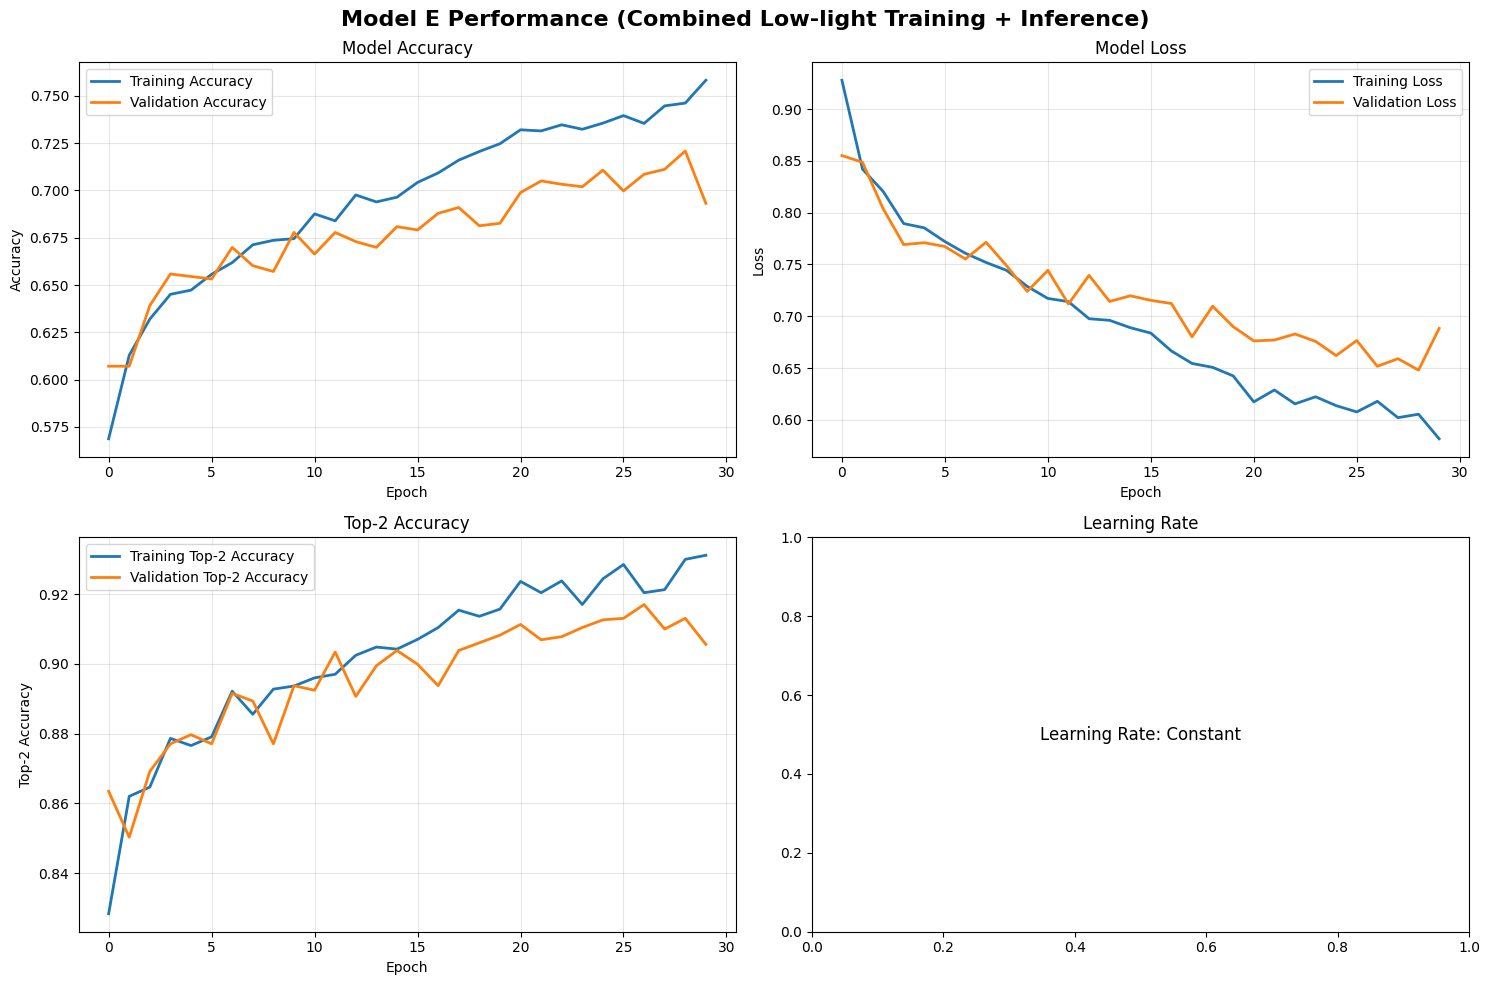

In [13]:
print("Step 8: Plotting and analyzing Model E results")

# Create plots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Model E Performance (Combined Low-light Training + Inference)', fontsize=16, fontweight='bold')

# Accuracy plot
axes[0, 0].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[0, 0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0, 0].set_title('Model Accuracy')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Loss plot
axes[0, 1].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0, 1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0, 1].set_title('Model Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Top-2 Accuracy plot
axes[1, 0].plot(history.history['top_2_accuracy'], label='Training Top-2 Accuracy', linewidth=2)
axes[1, 0].plot(history.history['val_top_2_accuracy'], label='Validation Top-2 Accuracy', linewidth=2)
axes[1, 0].set_title('Top-2 Accuracy')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Top-2 Accuracy')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Learning rate plot
if 'lr' in history.history:
    axes[1, 1].plot(history.history['lr'], label='Learning Rate', linewidth=2, color='red')
    axes[1, 1].set_title('Learning Rate Schedule')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Learning Rate')
    axes[1, 1].set_yscale('log')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
else:
    axes[1, 1].text(0.5, 0.5, 'Learning Rate: Constant',
                   horizontalalignment='center', verticalalignment='center',
                   transform=axes[1, 1].transAxes, fontsize=12)
    axes[1, 1].set_title('Learning Rate')

plt.tight_layout()
plt.savefig('ModelE_performance.png', dpi=300, bbox_inches='tight')
plt.show()


In [14]:
print("Step 9: Final model E evaluation")

# Calculate final metrics
final_train_accuracy = history.history['accuracy'][-1]
final_val_accuracy = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print("\n" + "="*60)
print("MODEL E FINAL RESULTS")
print("="*60)
print(f"Final Training Accuracy: {final_train_accuracy:.4f}")
print(f"Final Validation Accuracy: {final_val_accuracy:.4f}")
print(f"Final Training Loss: {final_train_loss:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")
print(f"Training Epochs: {len(history.history['accuracy'])}")
print(f"Best Validation Accuracy: {max(history.history['val_accuracy']):.4f}")
print("="*60)

# Save final results summary
results_summary = {
    'model_type': 'E_combined_lowlight',
    'training_strategy': 'mild_lowlight_preprocessing',
    'inference_strategy': 'mild_lowlight_preprocessing',
    'key_innovation': 'matched_training_testing_conditions',
    'preprocessing_parameters': {
        'gamma': 1.3,
        'brightness_reduction': 0.1,
        'noise_stddev': 0.03
    },
    'final_training_accuracy': float(final_train_accuracy),
    'final_validation_accuracy': float(final_val_accuracy),
    'final_training_loss': float(final_train_loss),
    'final_validation_loss': float(final_val_loss),
    'best_validation_accuracy': float(max(history.history['val_accuracy'])),
    'total_epochs_trained': len(history.history['accuracy']),
    'dataset_info': {
        'training_samples': train_generator.samples,
        'validation_samples': validation_generator.samples,
        'class_names': CONFIG["class_names"]
    }
}

with open('model_E_results_summary.json', 'w') as f:
    json.dump(results_summary, f, indent=4)

Step 9: Final model E evaluation

MODEL E FINAL RESULTS
Final Training Accuracy: 0.7582
Final Validation Accuracy: 0.6932
Final Training Loss: 0.5818
Final Validation Loss: 0.6883
Training Epochs: 30
Best Validation Accuracy: 0.7208
